In [4]:
#data handling
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [5]:
#Load Dataset
df=pd.read_csv("dirty_cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [7]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [8]:
#Checking missing values before handling
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [9]:
#Checking dupicated
df.duplicated().sum()

np.int64(0)

In [10]:
#Checking unique values before handling
df['Quantity'].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [11]:
#Converting object in numeric datatype
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

#Filling with median after handling
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

#Again convert into integer.
df['Quantity'] = df['Quantity'].astype('Int64')

In [12]:
#verify after cleaning
df['Quantity'].unique()

<IntegerArray>
[2, 4, 5, 3, 1]
Length: 5, dtype: Int64

In [13]:
#Check The Item
df['Item'].value_counts(dropna=False)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

In [14]:
#cleaning the Item column
df['Item'] = df['Item'].replace(['ERROR', 'UNKNOWN'], 'Unknown')

#fill the value
df['Item'] = df['Item'].fillna('Unknown')

In [15]:
#to check the missing values
df['Item'].isnull().sum()

np.int64(0)

In [16]:
#to verify after cleaning
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: count, dtype: int64

In [17]:
#Checking unique values before handling
df['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [18]:
#Cleaning the Price Per Unit column
df['Price Per Unit'] = df['Price Per Unit'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())

In [19]:
#to verify after cleaning
df['Price Per Unit'].unique()
df['Price Per Unit'].isnull().sum()

np.int64(0)

In [20]:
#Checking unique values before handling
df['Total Spent'].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [37]:
#Cleaning the Total spent column
df['Total Spent'] = df['Total Spent'].replace(['ERROR', 'UNKNOWN'], np.nan)
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())

In [38]:
#to verify after cleaning
df['Total Spent'].unique()
#df['Total Spent'].isnull().sum()

array([ 4. , 12. ,  8. , 10. , 20. ,  9. , 16. , 15. , 25. ,  5. ,  3. ,
        6. ,  2. ,  1. ,  7.5,  4.5,  1.5])

In [23]:
#Check the payment method
df['Payment Method'].value_counts(dropna=False)

Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

In [24]:
#Cleaning the Payment method Column
df['Payment Method'] = df['Payment Method'].replace(['ERROR', 'UNKNOWN'], 'Unknown')
df['Payment Method'] = df['Payment Method'].fillna('Unknown')

In [25]:
#Verify after cleaing
df['Payment Method'].value_counts(dropna=False)

Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

In [26]:
#Drop the location because there is so many missing values.
df.drop(['Location'], axis=1, inplace=True)

In [27]:
#Checking datatype
df.dtypes

Transaction ID       object
Item                 object
Quantity              Int64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Transaction Date     object
dtype: object

In [28]:
#convert into date datatype :
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [29]:
#Fill the Transaction values
df['Transaction Date'] = df['Transaction Date'].ffill()

In [30]:
#To verify the transaction column
df['Transaction Date'].isnull().sum()

np.int64(0)

In [31]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                     Int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Transaction Date    datetime64[ns]
dtype: object

In [32]:
#checking missing values after handling missing values.
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Transaction Date    0
dtype: int64

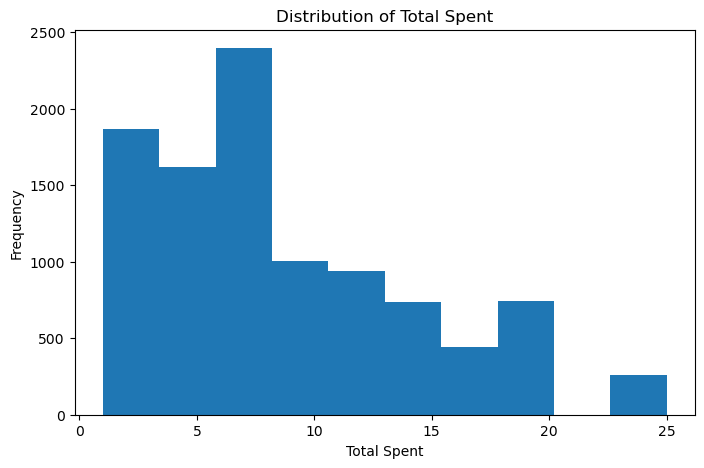

In [39]:
# Histogram of Total Spent
plt.figure(figsize=(8,5))
plt.hist(df['Total Spent'])

plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

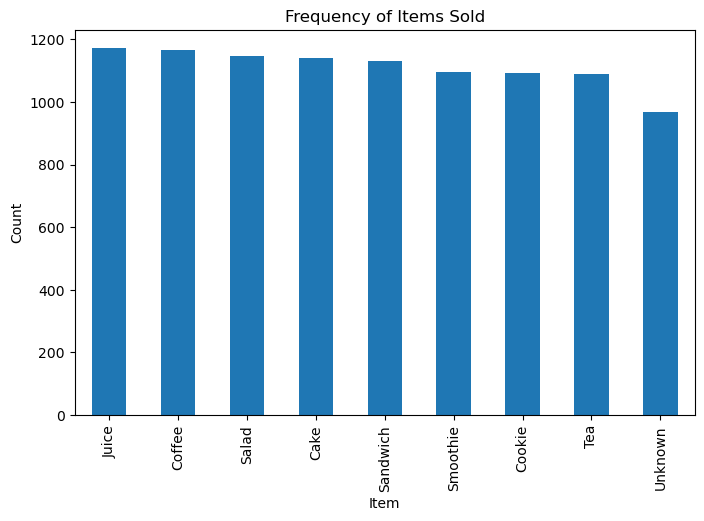

In [41]:
# Bar Chart of Item Sales
#The bar chart shows the frequency of each item sold
plt.figure(figsize=(8,5))
df['Item'].value_counts().plot(kind='bar')

plt.title('Frequency of Items Sold')
plt.xlabel('Item')
plt.ylabel('Count')
plt.show()

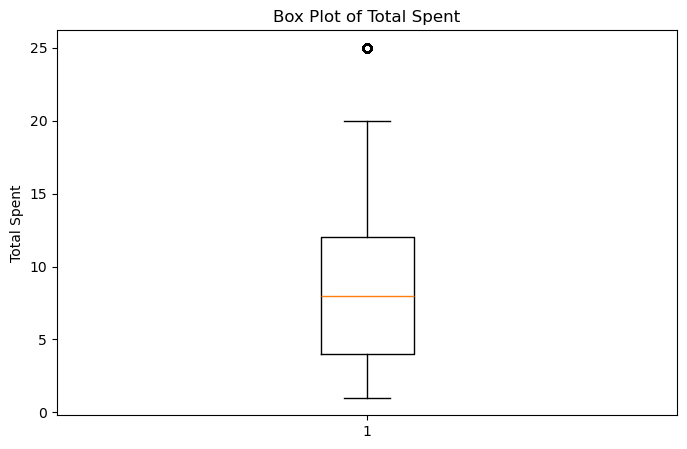

In [43]:
# Box Plot of Total Spent
#The box plot summarizes the distribution of Total Spent and helps identify outliers and the spread of transaction amounts.
plt.figure(figsize=(8,5))
plt.boxplot(df['Total Spent'])

plt.title('Box Plot of Total Spent')
plt.ylabel('Total Spent')
plt.show()

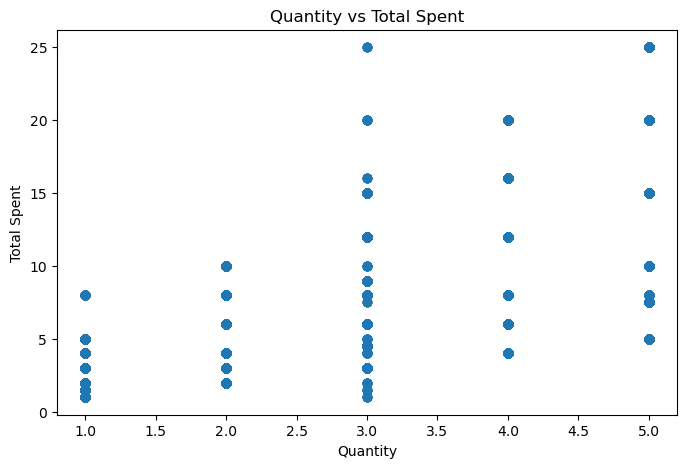

In [46]:
# Scatter Plot between Quantity and Total Spent
#The scatter plot shows the relationship between Quantity purchased and Total Spent.
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Total Spent'], alpha=0.5)

plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

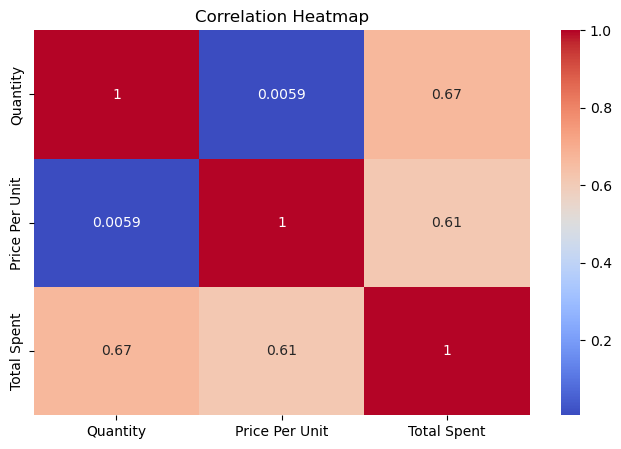

In [47]:
# Correlation Heatmap of Numerical Variables
#The heatmap displays the correlation between numerical variables.
plt.figure(figsize=(8,5))

numeric_df = df[['Quantity', 'Price Per Unit', 'Total Spent']]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [55]:
#Descriptive Statistics
# Mean
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].mean())

Quantity           3.0271
Price Per Unit    2.95265
Total Spent       8.87795
dtype: Float64


In [56]:
# Median
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].median())

Quantity          3.0
Price Per Unit    3.0
Total Spent       8.0
dtype: Float64


In [57]:
# Mode
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].mode())

   Quantity  Price Per Unit  Total Spent
0         3             3.0          8.0


In [58]:
# Standard Deviation
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].std())

Quantity          1.384614
Price Per Unit     1.24396
Total Spent        5.86059
dtype: Float64


In [59]:
# Variance
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].var())

Quantity           1.917157
Price Per Unit     1.547438
Total Spent       34.346513
dtype: Float64


In [60]:
# Minimum
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].min())

# Maximum
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].max())

Quantity          1.0
Price Per Unit    1.0
Total Spent       1.0
dtype: Float64
Quantity           5.0
Price Per Unit     5.0
Total Spent       25.0
dtype: Float64


In [61]:
# Quartiles
print(df[['Quantity', 'Price Per Unit', 'Total Spent']].quantile([0.25, 0.50, 0.75]))

      Quantity  Price Per Unit  Total Spent
0.25       2.0             2.0          4.0
0.50       3.0             3.0          8.0
0.75       4.0             4.0         12.0


In [62]:
# IQR
Q1 = df[['Quantity', 'Price Per Unit', 'Total Spent']].quantile(0.25)
Q3 = df[['Quantity', 'Price Per Unit', 'Total Spent']].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

Quantity          2.0
Price Per Unit    2.0
Total Spent       8.0
dtype: Float64


In [63]:
#Hypothesis Formulation and Statistical Testing
#Research Question
#Is there a significant relationship between the quantity of items purchased and the total amount spent by customers in the cafe?
#Hypotheses
#Null Hypothesis (H₀)
#There is no significant relationship between Quantity and Total Spent.

#Alternative Hypothesis (H₁)
#There is a significant relationship between Quantity and Total Spent.

#Statistical Test
#Pearson Correlation Test is used because both variables are numerical.
corr, p_value = stats.pearsonr(df['Quantity'], df['Total Spent'])

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

Correlation Coefficient: 0.6688206080029755
P-value: 0.0


In [64]:
#Decision Rule
#Interpertation
#p-value < 0.05 = significance relationship exists.
#p-value > 0.05 = No significance relationship.
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [ ]:
#Interpretation and Conclusion

#1.Interpretation of Findings
Descriptive Statistics
The analysis showed variation in customer transactions. Most purchases are small, with moderate differences in spending patterns.

Data Visualization
The histogram showed most transactions are low-value. The bar chart showed Juice, Coffee, and Cake as top-selling items. 
The scatter plot indicated a positive relationship between Quantity and Total Spent, and the heatmap confirmed strong 
correlations among numerical variables.

Hypothesis Test
The Pearson correlation test showed a significant positive relationship between Quantity and Total Spent (p < 0.05), 
so the null hypothesis was rejected.

#2.Key Insights
1.Most customers buy small quantities.
2.Coffee, Juice, and Cake are the most popular items.
3.Higher quantity leads to higher spending.
4.Price and quantity strongly influence total sales.
    
#3.Conclusion
The analysis shows clear patterns in cafe sales. Customer spending increases with quantity, and a few items dominate sales. 
The results confirm that purchasing behavior is strongly influenced by order size and product type.